In [1]:
import transformers
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten") #'microsoft/trocr-base-handwritten'
model = VisionEncoderDecoderModel.from_pretrained('./checkpoint_eval_2014_small_stage1_new_image/checkpoint-19000')


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 384,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": false,
  "transformers_version": "4.48.1"
}

Config of the decoder: <class 'transformers.models.trocr.modeling_trocr.TrOCRForCausalLM'> is overwritten by shared deco

In [2]:
from PIL import Image, ImageEnhance
import cv2, numpy as np

img_path = 'cub3.jpg'  #'./data2/2014/18_em_1.bmp'   './data2/train/2_em_7.bmp'

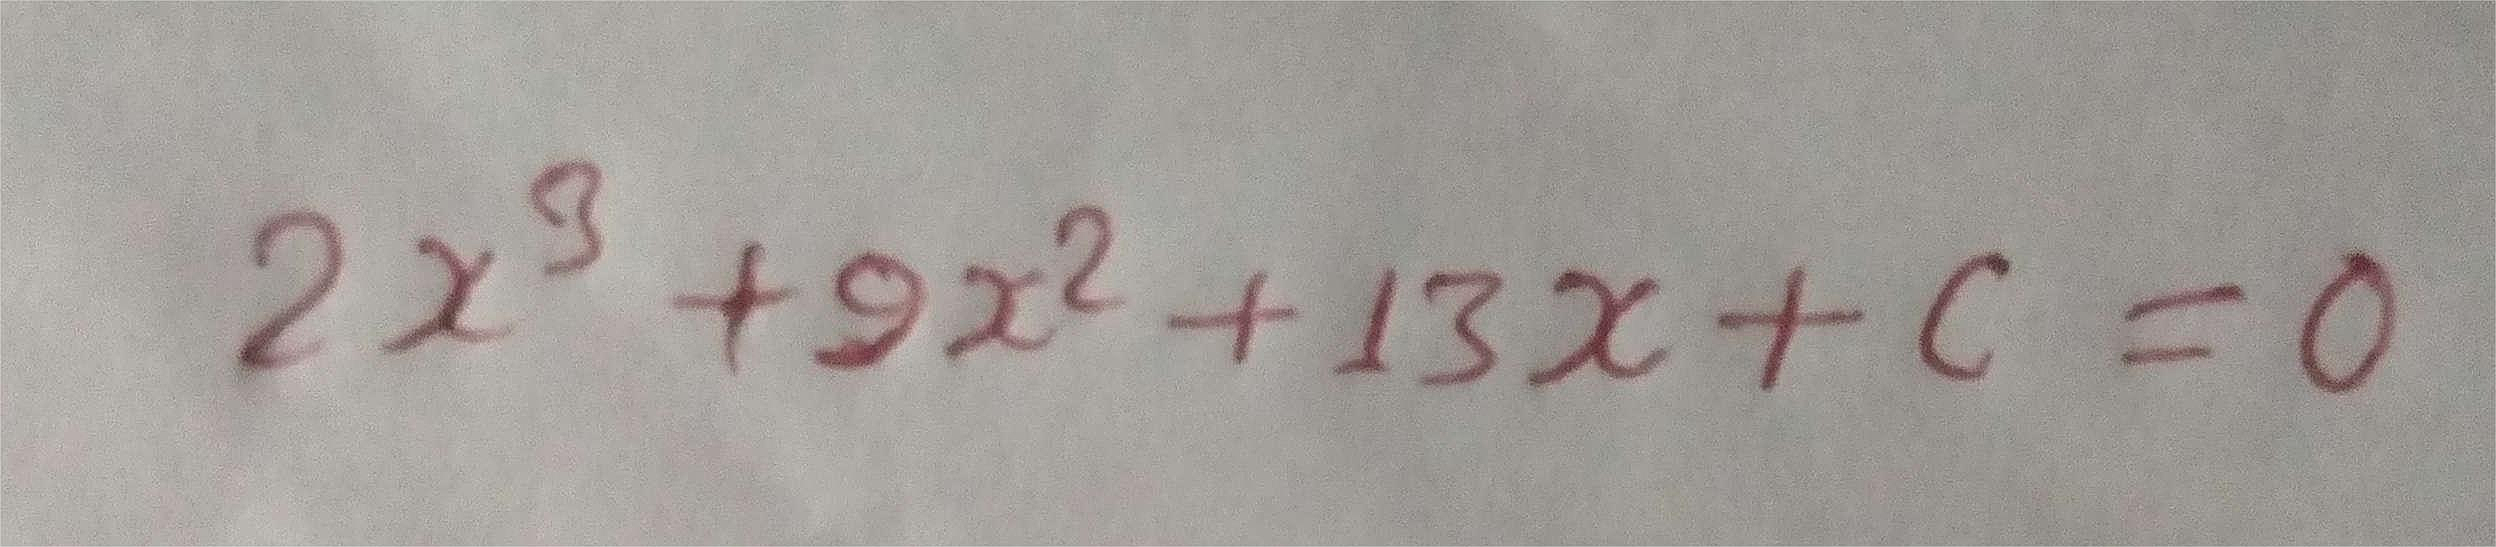

In [3]:

img = Image.open(img_path).convert("RGB")
img = ImageEnhance.Sharpness(img).enhance(2.0)
# img = ImageEnhance.Brightness(img).enhance(2)
# img = ImageEnhance.Color(img).enhance(0.0)


# Display or save
img

In [4]:
pixel_values = processor(img, return_tensors="pt").pixel_values
print(pixel_values)
print(pixel_values.shape)

tensor([[[[0.4902, 0.4667, 0.4824,  ..., 0.2549, 0.2627, 0.2784],
          [0.3412, 0.3490, 0.3569,  ..., 0.1137, 0.0902, 0.1529],
          [0.4118, 0.3882, 0.3725,  ..., 0.1294, 0.1216, 0.1686],
          ...,
          [0.4431, 0.4275, 0.4118,  ..., 0.1765, 0.1765, 0.1686],
          [0.4275, 0.4039, 0.4118,  ..., 0.1686, 0.1373, 0.1608],
          [0.5216, 0.4980, 0.5059,  ..., 0.3020, 0.2941, 0.3020]],

         [[0.4667, 0.4431, 0.4588,  ..., 0.2392, 0.2392, 0.2549],
          [0.3176, 0.3255, 0.3333,  ..., 0.0980, 0.0667, 0.1294],
          [0.3882, 0.3647, 0.3490,  ..., 0.1137, 0.0980, 0.1451],
          ...,
          [0.4196, 0.4039, 0.3961,  ..., 0.1529, 0.1451, 0.1373],
          [0.4196, 0.4039, 0.3961,  ..., 0.1529, 0.1373, 0.1608],
          [0.5137, 0.4902, 0.4824,  ..., 0.2784, 0.2863, 0.2941]],

         [[0.4275, 0.4039, 0.4196,  ..., 0.2000, 0.2000, 0.2157],
          [0.2784, 0.2863, 0.2941,  ..., 0.0588, 0.0275, 0.0902],
          [0.3490, 0.3255, 0.3098,  ..., 0

greedy search

In [5]:
generated_ids = model.generate(pixel_values)
generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Recognized Latex Text:", generated_text)

Recognized Latex Text: 2 x ^ { 3 } + s x 2 + 1 3 x + c = 0


beam search

In [ ]:
beam_output = model.generate(
    pixel_values, 
    num_beams=10, 
    early_stopping=True,
    num_return_sequences=5,
    max_length = 490
    #no_repeat_ngram_size = 3
)
print(processor.batch_decode(beam_output, skip_special_tokens=True)[0])
print(processor.batch_decode(beam_output, skip_special_tokens=True)[1])
print(processor.batch_decode(beam_output, skip_special_tokens=True)[2])
print(processor.batch_decode(beam_output, skip_special_tokens=True)[3])
print(processor.batch_decode(beam_output, skip_special_tokens=True)[4])


#max_length = 預測的字數
#no_repeat_ngram_size = 0(無窮大) 不出現重複的字幾次

Top-k

In [ ]:
sample_output = model.generate(
    pixel_values, 
    do_sample=True, 
    top_k=50
)
print(processor.batch_decode(sample_output, skip_special_tokens=True)[0])

In [ ]:
def ocr_image(src_img):  #greedy
 pixel_values = processor(images=src_img, return_tensors="pt").pixel_values
 generated_ids = model.generate(pixel_values)
 return processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

In [ ]:
def ocr_image2(src_img):  #beam search
 pixel_values = processor(images=src_img, return_tensors="pt").pixel_values
 generated_ids = model.generate(pixel_values, num_beams=5,early_stopping=True)
 return processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

In [ ]:
ocr_image(img)

ocr_image2(img)